In [1]:
from base_models import DATA_PATH
from rheology_parameter_uncertainty_budget import (
    get_parameter_values_and_sigma_for_all_pod_parametrizations,
)

initial_solutions = {}
cross_consistence_solutions = {}

for fix_option in ["lam", "lqm"]:

    parameters = ["LAM", "LDM"] if fix_option == "lqm" else ["LQM", "LDM"]

    cross_consistence_solutions |= get_parameter_values_and_sigma_for_all_pod_parametrizations(
        parameters=parameters,
        path=DATA_PATH.joinpath("listing_cross_consistence/fix_" + fix_option),
        fix_option=fix_option.upper(),
        alpha=0.29432578921708,
    )

    initial_solutions |= get_parameter_values_and_sigma_for_all_pod_parametrizations(
        parameters=parameters,
        path=DATA_PATH.joinpath("listing_fix_" + fix_option + "_fix_ltm/sigma_E-13"),
        fix_option=fix_option.upper()
    )


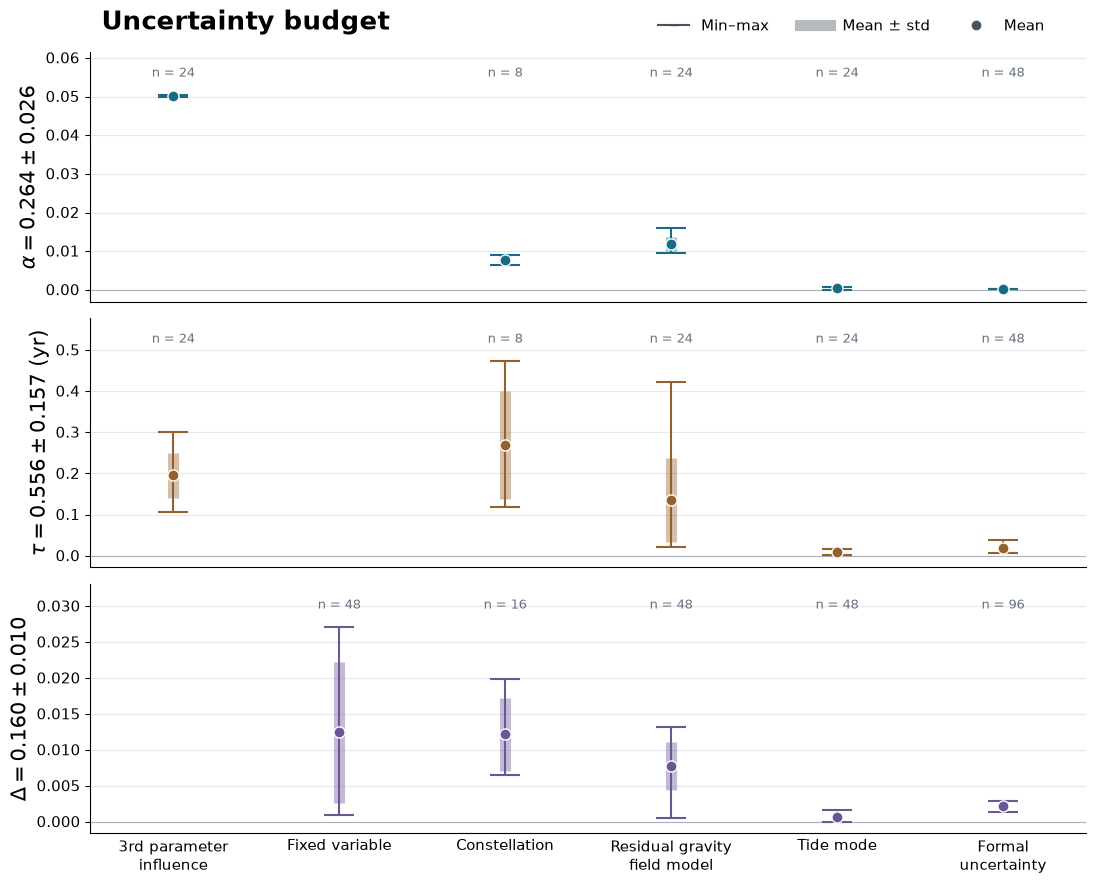

In [2]:
from rheology_parameter_uncertainty_budget import (
    normalize_solutions,
    compute_uncertainty_samples,
    summarize_uncertainties,
    plot_uncertainty_budget,
)
from matplotlib.pyplot import show

records = normalize_solutions({
    "initial": initial_solutions,
    "cross_consistence": cross_consistence_solutions,
})

samples, diagnostics = compute_uncertainty_samples(records, metric="range")
summary = summarize_uncertainties(samples, ddof=0)
fig, axes = plot_uncertainty_budget(summary=summary, records=records)
fig.savefig("rheology_uncertainty_budget.pdf")
show()